<a href="https://colab.research.google.com/github/di-claro-batera/faculdade_data_science/blob/main/Analise_de_Sentimento.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Processamento de Linguagem Natural - Análise de Sentimentos

Seguiremos os seguintes passos:
* Pré-processar dados de texto para BERT e construir o conjunto de dados PyTorch (tokenização, máscaras de atenção e padding)
* Usar transfer learning para construir um classificador de sentimentos usando a biblioteca Transformers da Hugging Face
* Avaliar o modelo em dados de teste
* Prever o sentimento no texto bruto

# Instalando as bibliotecas

Transformers e suas dependências

In [2]:
!pip install -q -U watermark
!pip install -qq transformers[sentencepiece]
%reload_ext watermark
%watermark -v -p numpy,pandas,torch,transformers[sentencepiece]

Python implementation: CPython
Python version       : 3.12.12
IPython version      : 7.34.0

numpy                      : 2.0.2
pandas                     : 2.2.2
torch                      : 2.10.0+cu128
transformers[sentencepiece]: unknown



# Pacotes e Configurações

In [7]:
import transformers
from transformers import BertModel, BertTokenizer, get_linear_schedule_with_warmup
import torch
from torch.optim import AdamW

import numpy as np
import pandas as pd
import seaborn as sns
from pylab import rcParams
import matplotlib.pyplot as plt
from matplotlib import rc
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
from collections import defaultdict
from textwrap import wrap

from torch import nn, optim
from torch.utils.data import Dataset, DataLoader
import torch.nn.functional as F

%matplotlib inline
%config InlineBackend.figure_format='retina'

sns.set(style='whitegrid', palette='muted', font_scale=1.2)

HAPPY_COLORS_PALLETE = ["#01BEFE", "#FFDD00", "#FF7D00", "#FF006D", "#ADFF02", "#8F00FF"]

sns.set_palette(sns.color_palette(HAPPY_COLORS_PALLETE))

rcParams['figure.figsize'] = 6, 4

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
device

device(type='cuda', index=0)

In [16]:
!gdown --id 1S6qMioqPJjyBLpLVz4gmRTnJHnjitnuV
!gdown --id 1zdmewp7ayS4js4VtrJEHzAheSW-5NBZv

/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From: https://drive.google.com/uc?id=1S6qMioqPJjyBLpLVz4gmRTnJHnjitnuV
To: /content/apps.csv
100% 134k/134k [00:00<00:00, 83.5MB/s]
/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From: https://drive.google.com/uc?id=1zdmewp7ayS4js4VtrJEHzAheSW-5NBZv
To: /content/reviews.csv
100% 7.17M/7.17M [00:00<00:00, 113MB/s]


In [17]:
df = pd.read_csv("reviews.csv")
df.head()

,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,sortOrder,appId
0,Andrew Thomas,https://lh3.googleusercontent.com/a-/AOh14GiHd...,Update: After getting a response from the deve...,1,21,4.17.0.3,2020-04-05 22:25:57,"According to our TOS, and the term you have ag...",2020-04-05 15:10:24,most_relevant,com.anydo
1,Craig Haines,https://lh3.googleusercontent.com/-hoe0kwSJgPQ...,Used it for a fair amount of time without any ...,1,11,4.17.0.3,2020-04-04 13:40:01,It sounds like you logged in with a different ...,2020-04-05 15:11:35,most_relevant,com.anydo
2,steven adkins,https://lh3.googleusercontent.com/a-/AOh14GiXw...,Your app sucks now!!!!! Used to be good but no...,1,17,4.17.0.3,2020-04-01 16:18:13,This sounds odd! We are not aware of any issue...,2020-04-02 16:05:56,most_relevant,com.anydo
3,Lars Panzerbjørn,https://lh3.googleusercontent.com/a-/AOh14Gg-h...,"It seems OK, but very basic. Recurring tasks n...",1,192,4.17.0.2,2020-03-12 08:17:34,We do offer this option as part of the Advance...,2020-03-15 06:20:13,most_relevant,com.anydo
4,Scott Prewitt,https://lh3.googleusercontent.com/-K-X1-YsVd6U...,Absolutely worthless. This app runs a prohibit...,1,42,4.17.0.2,2020-03-14 17:41:01,We're sorry you feel this way! 90% of the app ...,2020-03-15 23:45:51,most_relevant,com.anydo


In [19]:
df.shape

(15746, 11)

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15746 entries, 0 to 15745
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   userName              15746 non-null  object
 1   userImage             15746 non-null  object
 2   content               15746 non-null  object
 3   score                 15746 non-null  int64 
 4   thumbsUpCount         15746 non-null  int64 
 5   reviewCreatedVersion  13533 non-null  object
 6   at                    15746 non-null  object
 7   replyContent          7367 non-null   object
 8   repliedAt             7367 non-null   object
 9   sortOrder             15746 non-null  object
 10  appId                 15746 non-null  object
dtypes: int64(2), object(9)
memory usage: 1.3+ MB


Text(0, 0.5, 'Score')

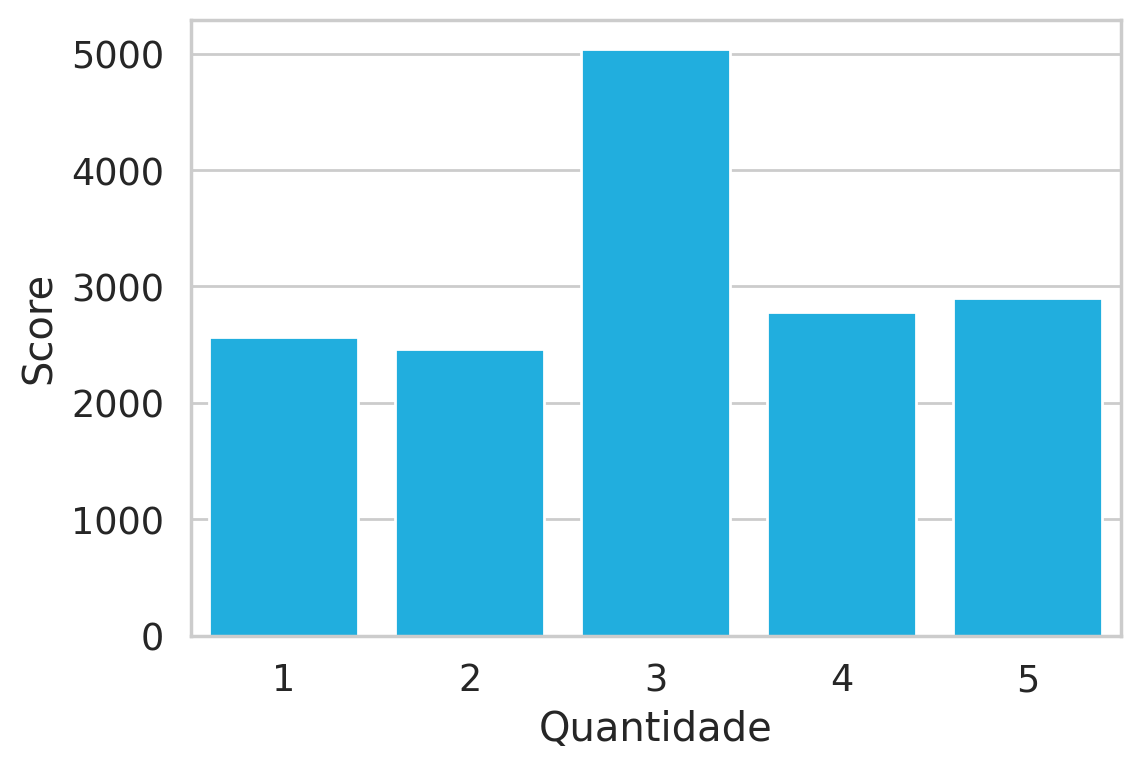

In [21]:
sns.countplot(data=df, x=df.score)
plt.xlabel('Quantidade')
plt.ylabel('Score')

há um desbalanceamento, mas tudo bem. Vamos converter o dataset para sentimentos negativos, neutros e positivos:

In [22]:
def to_sentiment(rating):
  rating = int(rating)
  if rating <= 2:
    return 0 #negativo
  elif rating == 3:
    return 1 #neutro
  else:
    return 2 #positivo

df['sentiment'] = df.score.apply(to_sentiment)

In [23]:
class_names = ["Negativo", "Neutro", "Positivo"]

/tmp/ipykernel_326/1734882786.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(class_names);


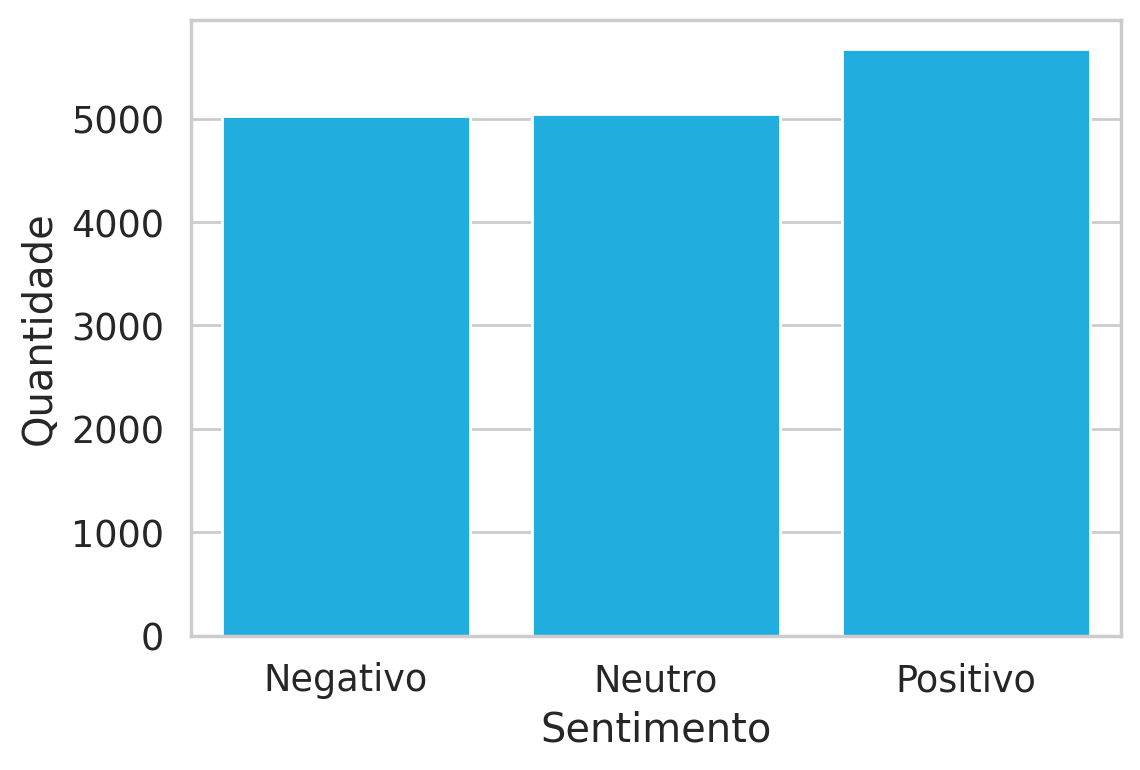

In [25]:
ax = sns.countplot(data=df, x=df.sentiment)
plt.ylabel('Quantidade')
plt.xlabel('Sentimento');
ax.set_xticklabels(class_names);

# Pré-processamento dos dados

Sabendo que os algoritmos de AM não trabalham diretamente com textos brutos, precisamos converter os textos em números. O BERT ainda exige alguns requisitos específicos:
* Adicionar tokens especiais para separar sentenças e realizar a classificação
* Passar sequências de comprimento/tamanho fixo: introduzir padding(preenchimento)
* Criar uma matriz de 0s (pad token) e 1s (real token) chamada máscara de atenção.

A bilioteca Transformers oferece uma ampla variedade de modelos de Transformers (incluindo BERT). Funciona com TensorFlow e PyTorch, e também inclui tokenizadores pré-construídos que fazem esse trabalho "pesado".

In [26]:
PRE_TRAINED_MODEL_NAME = 'bert-base-cased'

In [27]:
tokenizer = BertTokenizer.from_pretrained(PRE_TRAINED_MODEL_NAME)

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [28]:
sample_txt = "When was I last outside? I am stuck at home for 2 weeks."

In [29]:
tokens = tokenizer.tokenize(sample_txt)
token_ids = tokenizer.convert_tokens_to_ids(tokens)

print(f'Sentença: {sample_txt}')
print(f'Tokens: {tokens}')
print(f'Tokens IDs: {token_ids}')

Sentença: When was I last outside? I am stuck at home for 2 weeks.
Tokens: ['When', 'was', 'I', 'last', 'outside', '?', 'I', 'am', 'stuck', 'at', 'home', 'for', '2', 'weeks', '.']
Tokens IDs: [1332, 1108, 146, 1314, 1796, 136, 146, 1821, 5342, 1120, 1313, 1111, 123, 2277, 119]


In [30]:
tokenizer.sep_token, tokenizer.sep_token_id

('[SEP]', 102)

In [31]:
tokenizer.cls_token, tokenizer.cls_token_id

('[CLS]', 101)

In [32]:
tokenizer.pad_token, tokenizer.pad_token_id

('[PAD]', 0)

In [33]:
tokenizer.unk_token, tokenizer.unk_token_id

('[UNK]', 100)

In [35]:
encoding = tokenizer(
    sample_txt,
    max_length=32,
    add_special_tokens=True, # Adiciona [CLS] e [SEP]
    return_token_type_ids=False,
    padding='max_length',
    truncation=True,
    return_attention_mask=True,
    return_tensors='pt', # Retorna tensores PyTorch
)

print(encoding.keys())
encoding

KeysView({'input_ids': tensor([[ 101, 1332, 1108,  146, 1314, 1796,  136,  146, 1821, 5342, 1120, 1313,
         1111,  123, 2277,  119,  102,    0,    0,    0,    0,    0,    0,    0,
            0,    0,    0,    0,    0,    0,    0,    0]]), 'attention_mask': tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0]])})


{'input_ids': tensor([[ 101, 1332, 1108,  146, 1314, 1796,  136,  146, 1821, 5342, 1120, 1313,
         1111,  123, 2277,  119,  102,    0,    0,    0,    0,    0,    0,    0,
            0,    0,    0,    0,    0,    0,    0,    0]]), 'attention_mask': tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0]])}

In [36]:
print(len(encoding['input_ids'][0]))
encoding['input_ids'][0]

32


tensor([ 101, 1332, 1108,  146, 1314, 1796,  136,  146, 1821, 5342, 1120, 1313,
        1111,  123, 2277,  119,  102,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0])

In [37]:
print(len(encoding['attention_mask'][0]))
encoding['attention_mask']

32


tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0]])

In [38]:
tokenizer.convert_ids_to_tokens(encoding['input_ids'][0])

['[CLS]',
 'When',
 'was',
 'I',
 'last',
 'outside',
 '?',
 'I',
 'am',
 'stuck',
 'at',
 'home',
 'for',
 '2',
 'weeks',
 '.',
 '[SEP]',
 '[PAD]',
 '[PAD]',
 '[PAD]',
 '[PAD]',
 '[PAD]',
 '[PAD]',
 '[PAD]',
 '[PAD]',
 '[PAD]',
 '[PAD]',
 '[PAD]',
 '[PAD]',
 '[PAD]',
 '[PAD]',
 '[PAD]']

# Escolhendo o comprimento da sequência
BERT trabalha com sequências de comprimento fixo. Usaremos uma estratégia simples para escolher o comprimento máximo. Vamos armazenar o comprimento do token de cada revisão e plotar a distribuição

In [39]:
token_lens = []
for txt in df.content:
  tokens = tokenizer.encode(txt, max_length=512)
  token_lens.append(len(tokens))

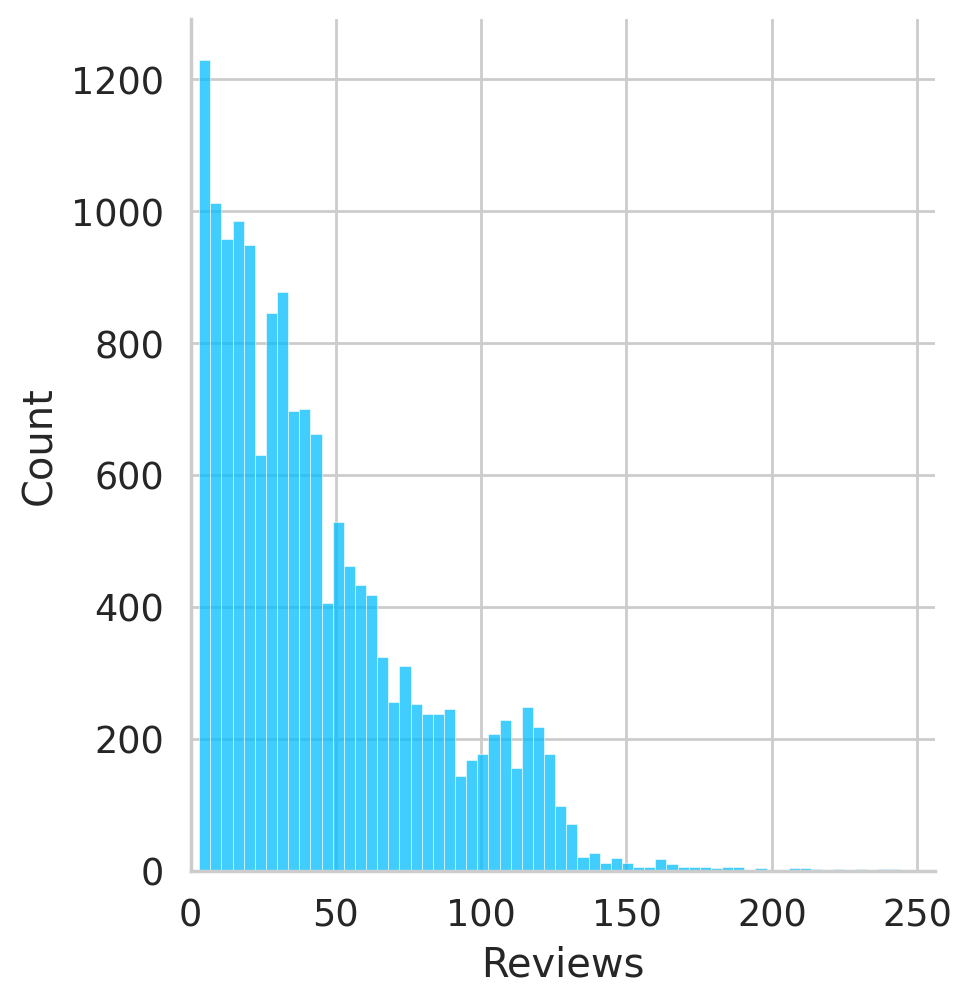

In [41]:
sns.displot(token_lens)
plt.xlim([0, 256]);
plt.xlabel('Tokens');
plt.xlabel('Reviews');

A maioria dos reviews parece conter menos que 128 tokens


In [42]:
MAX_LEN = 128

Temos todos os blocos de construção para criar um conjunto de dados Pytorch.

In [51]:
class GPReviewDataset(Dataset):

  def __init__(self, reviews, targets, tokenizer, max_len):
    self.reviews = reviews
    self.targets = targets
    self.tokenizer = tokenizer
    self.max_len = max_len

  def __len__(self):
    return len(self.reviews)

  def __getitem__(self, item):
    review = str(self.reviews[item])
    target = self.targets[item]

    # Alterado de self.tokenizer.encode_plus para self.tokenizer(...)
    encoding = self.tokenizer(
        review,
        add_special_tokens=True,
        max_length=self.max_len,
        return_token_type_ids=False,
        padding='max_length',
        truncation=True,
        return_attention_mask=True,
        return_tensors='pt',
    )

    return {
        'review_text': review,
        'input_ids': encoding['input_ids'].flatten(),
        'attention_mask': encoding['attention_mask'].flatten(),
        'targets': torch.tensor(target, dtype=torch.long)
    }

In [52]:
df_train, df_test = train_test_split(df, test_size=0.1, random_state=RANDOM_SEED)
df_val, df_test = train_test_split(df_test, test_size=0.5, random_state=RANDOM_SEED)

In [53]:
df_train.shape, df_val.shape, df_test.shape

((14171, 12), (787, 12), (788, 12))

In [54]:
def create_data_loader(df, tokenizer, max_len, batch_size):
  ds = GPReviewDataset(
      reviews=df.content.to_numpy(),
      targets=df.sentiment.to_numpy(),
      tokenizer = tokenizer,
      max_len=max_len
  )

  return DataLoader(
      ds,
      batch_size=batch_size,
      num_workers=2
    )

In [55]:
BATCH_SIZE = 64

train_data_loader = create_data_loader(df_train, tokenizer, MAX_LEN, BATCH_SIZE)
val_data_loader = create_data_loader(df_val, tokenizer, MAX_LEN, BATCH_SIZE)
test_data_loader = create_data_loader(df_test, tokenizer, MAX_LEN, BATCH_SIZE)

In [56]:
data = next(iter(train_data_loader))
data.keys()

dict_keys(['review_text', 'input_ids', 'attention_mask', 'targets'])

In [57]:
print(data['input_ids'].shape)
print(data['attention_mask'].shape)
print(data['targets'].shape)

torch.Size([64, 128])
torch.Size([64, 128])
torch.Size([64])


# Classificação de sentimentos usando BERT e Hugging Face

In [58]:
bert_model = BertModel.from_pretrained(PRE_TRAINED_MODEL_NAME)

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/436M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [61]:
outputs = bert_model(
    input_ids= encoding['input_ids'],
    attention_mask= encoding['attention_mask']
)
last_hidden_state = outputs[0]
pooled_output = outputs[1]

In [63]:
class SentimentClassifier(nn.Module):
  def __init__(self, n_classes):
    super(SentimentClassifier, self).__init__()
    self.bert = BertModel.from_pretrained(PRE_TRAINED_MODEL_NAME)
    self.drop = nn.Dropout(p=0.3)
    self.out = nn.Linear(self.bert.config.hidden_size, n_classes)

  def forward(self, input_ids, attention_mask):
    _, pooled_output = self.bert(
    input_ids=input_ids,
    attention_mask=attention_mask, return_dict=False
    )

    output = self.drop(pooled_output)
    return self.out(output)

In [64]:
model = SentimentClassifier(len(class_names))
model = model.to(device)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [65]:
input_ids = data['input_ids'].to(device)
attention_mask = data['attention_mask'].to(device)

print(input_ids.shape)
print(attention_mask.shape)

torch.Size([64, 128])
torch.Size([64, 128])


In [66]:
F.softmax(model(input_ids, attention_mask), dim=1)

tensor([[0.2305, 0.1599, 0.6096],
        [0.1581, 0.3367, 0.5053],
        [0.2348, 0.3283, 0.4369],
        [0.1924, 0.3677, 0.4399],
        [0.2935, 0.2929, 0.4135],
        [0.2360, 0.2059, 0.5581],
        [0.1617, 0.2666, 0.5717],
        [0.1949, 0.2022, 0.6030],
        [0.2036, 0.2024, 0.5940],
        [0.2954, 0.2378, 0.4668],
        [0.1543, 0.2824, 0.5633],
        [0.2349, 0.2503, 0.5148],
        [0.2500, 0.3439, 0.4060],
        [0.2254, 0.3540, 0.4206],
        [0.1788, 0.2692, 0.5520],
        [0.1893, 0.2877, 0.5231],
        [0.1969, 0.3543, 0.4487],
        [0.1217, 0.5716, 0.3067],
        [0.1616, 0.2325, 0.6059],
        [0.0888, 0.4658, 0.4454],
        [0.2215, 0.4121, 0.3664],
        [0.1780, 0.3334, 0.4887],
        [0.1368, 0.2140, 0.6492],
        [0.2597, 0.2936, 0.4467],
        [0.1447, 0.2735, 0.5818],
        [0.2743, 0.3480, 0.3776],
        [0.1848, 0.2528, 0.5623],
        [0.1697, 0.2060, 0.6243],
        [0.1383, 0.2578, 0.6039],
        [0.222

## Treinamento

In [68]:
EPOCHS = 10

optimizer = AdamW(model.parameters(), lr=2e-5)
total_steps = len(train_data_loader) * EPOCHS

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=0,
    num_training_steps=total_steps
    )

loss_fn = nn.CrossEntropyLoss().to(device)

In [69]:
def train_epoch(
    model,
    data_loader,
    loss_fn,
    optimizer,
    device,
    scheduler,
    n_examples
  ):
  model = model.train()

  losses = []
  correct_predictions = 0

  for d in data_loader:
    input_ids = d["input_ids"].to(device)
    attention_mask = d["attention_mask"].to(device)
    targets = d["targets"].to(device)

    outputs = model(
        input_ids=input_ids,
        attention_mask=attention_mask
    )

    _, preds = torch.max(outputs, dim=1)
    loss = loss_fn(outputs, targets)

    correct_predictions += torch.sum(preds == targets)
    losses.append(loss.item())

    loss.backward()
    nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
    optimizer.step()
    scheduler.step()
    optimizer.zero_grad()

  return correct_predictions.double() / n_examples, np.mean(losses)


In [72]:
def eval_model(model, data_loader, loss_fn, device, n_examples):
  model = model.eval()

  losses = []
  correct_predictions = 0

  with torch.no_grad():
    for d in data_loader:
      input_ids = d["input_ids"].to(device)
      attention_mask = d["attention_mask"].to(device)
      targets = d["targets"].to(device)

      outputs = model(
          input_ids=input_ids,
          attention_mask=attention_mask
      )
      _, preds = torch.max(outputs, dim=1)
      loss = loss_fn(outputs, targets)

      correct_predictions += torch.sum(preds == targets)
      losses.append(loss.item())

  return correct_predictions.double() / n_examples, np.mean(losses)

In [74]:
%%time

history = defaultdict(list)
best_accuracy = 0

for epoch in range(EPOCHS):
  print(f'Epoch {epoch +1}/{EPOCHS}')
  print('-' * 10)

  train_acc, train_loss = train_epoch(
      model,
      train_data_loader,
      loss_fn,
      optimizer,
      device,
      scheduler,
      len(df_train)
  )

  print(f'Train loss{train_loss} accuracy {train_acc}')

  val_acc, val_loss = eval_model(
      model,
      val_data_loader,
      loss_fn,
      device,
      len(df_val)
  )

  print(f'Val loss {val_loss} accuracy {val_acc}')
  print()

  history['train_acc'].append(train_acc)
  history['train_loss'].append(train_loss)
  history['val_acc'].append(val_acc)
  history['val_loss'].append(val_loss)

  if val_acc > best_accuracy:
    torch.save(model.state_dict(), 'best_model_state.bin')
    best_accuracy = val_acc


Epoch 1/10
----------
Train loss0.3737548810538945 accuracy 0.8626772987086303
Val loss 0.5961000758867997 accuracy 0.7852604828462516

Epoch 2/10
----------
Train loss0.25209266888732845 accuracy 0.9129913203020253
Val loss 0.48521509537330043 accuracy 0.8462515883100381

Epoch 3/10
----------
Train loss0.1838057421080701 accuracy 0.9371251146708066
Val loss 0.47648449815236604 accuracy 0.8653113087674714

Epoch 4/10
----------
Train loss0.1424400403441207 accuracy 0.951520711311834
Val loss 0.4670134507692777 accuracy 0.8767471410419314

Epoch 5/10
----------
Train loss0.10048448459270436 accuracy 0.9657751746524593
Val loss 0.552171684228457 accuracy 0.8716645489199493

Epoch 6/10
----------
Train loss0.08382176664691451 accuracy 0.9707148401665373
Val loss 0.5967530470628005 accuracy 0.8716645489199493

Epoch 7/10
----------
Train loss0.07320129533659096 accuracy 0.9749488391786042
Val loss 0.6115141258789942 accuracy 0.8754764930114358

Epoch 8/10
----------
Train loss0.0579849492

In [75]:
cpu_train_acc = [x.cpu() for x in history['train_acc']]
cpu_val_acc = [x.cpu() for x in history['val_acc']]

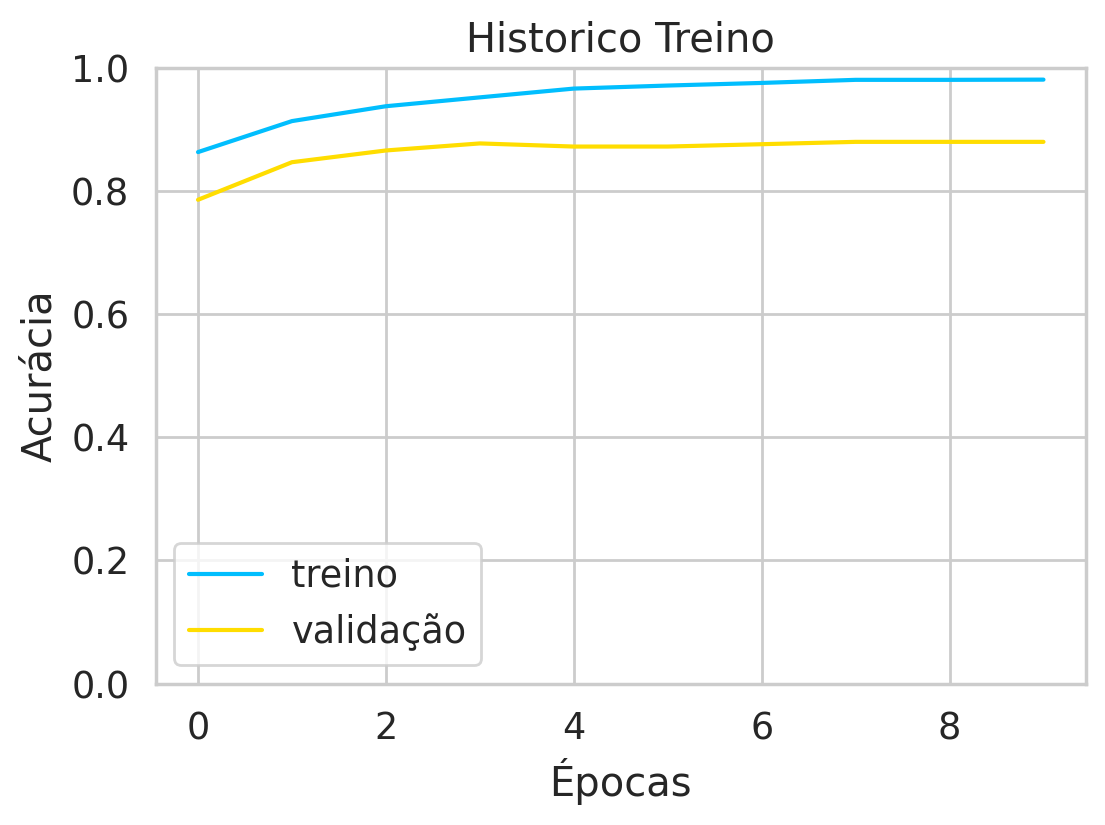

In [76]:
plt.plot(cpu_train_acc, label='treino')
plt.plot(cpu_val_acc, label='validação')

plt.title("Historico Treino")
plt.xlabel('Épocas')
plt.ylabel('Acurácia')
plt.legend()

plt.ylim([0,1]);

In [77]:
test_acc, _ = eval_model(
    model,
    test_data_loader,
    loss_fn,
    device,
    len(df_test)
)

test_acc.item()

0.8857868020304568

In [80]:
def get_predictions(model, data_loader):
  model = model.eval()

  review_texts = []
  predictions = []
  predictions_probs = []
  real_values = []

  with torch.no_grad():
    for d in data_loader:
      texts = d["review_text"]
      input_ids = d["input_ids"].to(device)
      attention_mask = d["attention_mask"].to(device)
      targets = d["targets"].to(device)

      outputs = model(
          input_ids=input_ids,
          attention_mask=attention_mask
      )
      _, preds = torch.max(outputs, dim=1)

      probs = F.softmax(outputs, dim=1)

      review_texts.extend(texts)
      predictions.extend(preds)
      predictions_probs.extend(probs)
      real_values.extend(targets)

  predictions = torch.stack(predictions).cpu()
  predictions_probs = torch.stack(predictions_probs).cpu()
  real_values = torch.stack(real_values).cpu()
  return review_texts, predictions, predictions_probs, real_values

In [81]:
y_review_texts, y_pred, y_pred_probs, y_test = get_predictions(
    model,
    test_data_loader
)

In [82]:
print(classification_report(y_test, y_pred, target_names = class_names))

              precision    recall  f1-score   support

    Negativo       0.94      0.87      0.90       245
      Neutro       0.81      0.88      0.84       254
    Positivo       0.91      0.91      0.91       289

    accuracy                           0.89       788
   macro avg       0.89      0.88      0.89       788
weighted avg       0.89      0.89      0.89       788



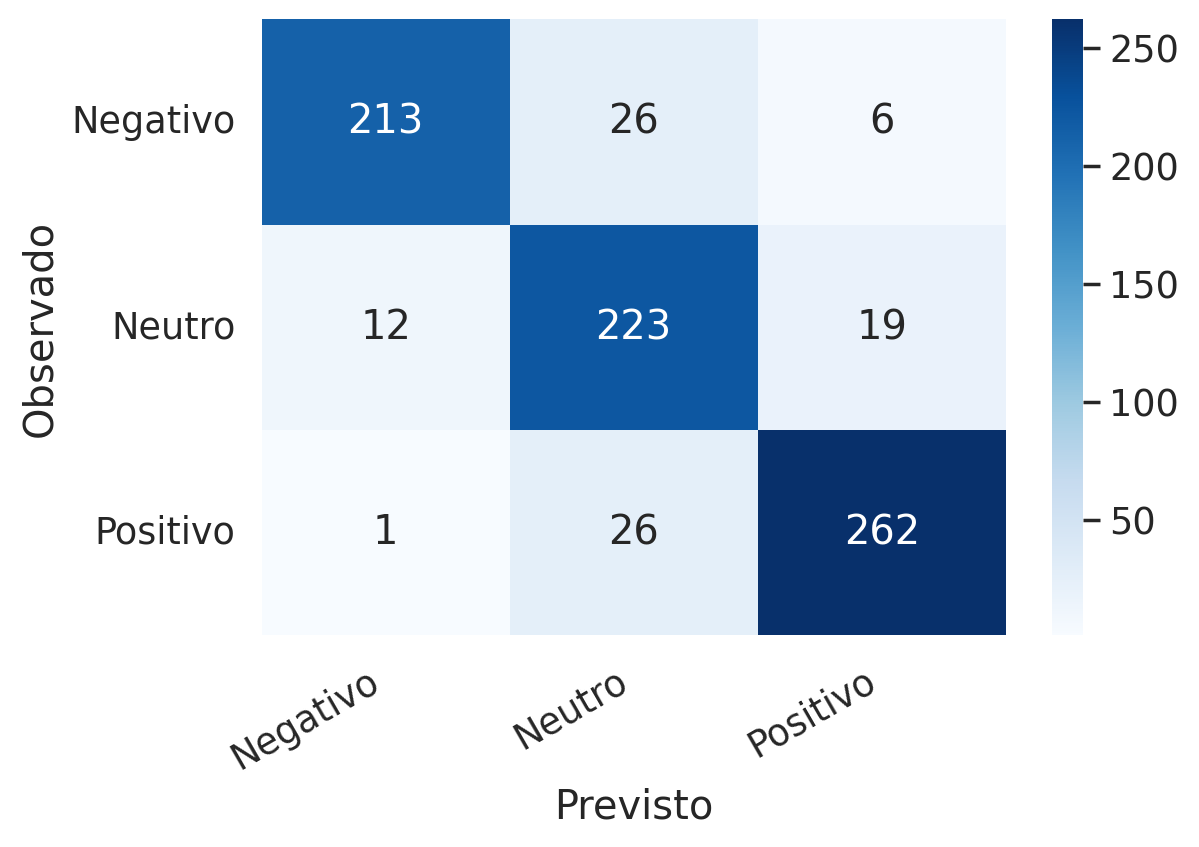

In [83]:
def show_confusion_matrix(confusion_matrix):
  hmap = sns.heatmap(confusion_matrix, annot=True, fmt="d", cmap="Blues")
  hmap.yaxis.set_ticklabels(hmap.yaxis.get_ticklabels(), rotation=0, ha='right')
  hmap.xaxis.set_ticklabels(hmap.xaxis.get_ticklabels(), rotation=30, ha='right')
  plt.ylabel('Observado')
  plt.xlabel('Previsto')

cm = confusion_matrix(y_test, y_pred)
df_cm = pd.DataFrame(cm, index=class_names, columns=class_names)
show_confusion_matrix(df_cm)

In [84]:
idx = 2
review_text = y_review_texts[idx]
true_sentiment = y_test[idx]
predict_sentiment = y_pred[idx]
pred_df = pd.DataFrame({
    'class_names': class_names,
    'probabilities': y_pred_probs[idx]
})

In [85]:
print("\n".join(wrap(review_text)))
print()
print(f'Sentimento real: {class_names[true_sentiment]}')
print(f'Sentimento previsto: {class_names[predict_sentiment]}')

I used to use Habitica, and I must say this is a great step up. I'd
like to see more social features, such as sharing tasks - only one
person has to perform said task for it to be checked off, but only
giving that person the experience and gold. Otherwise, the price for
subscription is too steep, thus resulting in a sub-perfect score. I
could easily justify $0.99/month or eternal subscription for $15. If
that price could be met, as well as fine tuning, this would be easily
worth 5 stars.

Sentimento real: Neutro
Sentimento previsto: Neutro
